In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

dataset = pd.read_csv("PokemonDatabase.csv")
dataset.head()

,Pokemon Id,Pokedex Number,Pokemon Name,Classification,Alternate Form Name,Original Pokemon ID,Legendary Type,Pokemon Height,Pokemon Weight,Primary Type,...,Base Stat Total,Catch Rate,Experience Growth,Experience Growth Total,Primary Egg Group,Secondary Egg Group,Egg Cycle Count,Pre-Evolution Pokemon Id,Evolution Details,Power Ranking
0,1,1,Bulbasaur,Seed Pokémon,NaN,NaN,NaN,0.7,6.9,Grass,...,318,45,Medium Slow,1059860,Monster,Grass,20,NaN,NaN,F
1,2,2,Ivysaur,Seed Pokémon,NaN,NaN,NaN,1.0,13.0,Grass,...,405,45,Medium Slow,1059860,Monster,Grass,20,1.0,Level 16,F
2,3,3,Venusaur,Seed Pokémon,NaN,NaN,NaN,2.0,100.0,Grass,...,525,45,Medium Slow,1059860,Monster,Grass,20,2.0,Level 32,C
3,4,3,Venusaur,Seed Pokémon,Mega,3.0,NaN,2.4,155.5,Grass,...,625,45,Medium Slow,1059860,Monster,Grass,20,NaN,NaN,B
4,1526,3,Venusaur,Seed Pokémon,Gigantamax,3.0,NaN,24.0,0.0,Grass,...,525,45,Medium Slow,1059860,Monster,Grass,20,NaN,NaN,S


In [22]:
from sklearn.model_selection import train_test_split

features = ["Health Stat", "Attack Stat", "Defense Stat", "Special Attack Stat", "Special Defense Stat", "Speed Stat", "Base Stat Total"]

tier_map = {'G': 0,'F': 1, 'E': 2, 'D': 3, 'C': 4, 'B': 5, 'A': 6, 'S': 7}
dataset['Power Ranking'] = dataset['Power Ranking'].astype(str).str.replace('"', '').str.strip().map(tier_map)

X = dataset[features].values
y = dataset["Power Ranking"].values

X_train, X_test_tmp, y_train, y_test_tmp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_dev, X_test, y_dev, y_test = train_test_split(X_test_tmp, y_test_tmp, test_size=0.50, random_state=42, stratify=y_test_tmp)

## Model using standard dataset

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_dev = scaler.transform(X_dev)
X_test = scaler.transform(X_test)

model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    alpha=0.0001,
    max_iter=2000,
    random_state=42
)

model.fit(X_train, y_train)

,hidden_layer_sizes,"(10,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,2000
,shuffle,True
,random_state,42


### Accuracy

In [24]:
y_train_pred = model.predict(X_train)
y_dev_pred = model.predict(X_dev)

train_accuracy = accuracy_score(y_train, y_train_pred)
print("Train accuracy:", train_accuracy)
dev_accuracy = accuracy_score(y_dev, y_dev_pred)
print("Dev accuracy:", dev_accuracy)

class_report = classification_report(y_dev, y_dev_pred, target_names=["G", "F", "E", "D", "C", "B", "A", "S"])
print("Classification Report:\n", class_report)

Train accuracy: 0.7351694915254238
Dev accuracy: 0.698019801980198
Classification Report:
               precision    recall  f1-score   support

           G       0.92      0.92      0.92        26
           F       0.95      1.00      0.97        55
           E       0.72      0.93      0.81        41
           D       0.25      0.19      0.21        16
           C       0.29      0.14      0.19        14
           B       0.39      0.55      0.46        20
           A       0.38      0.29      0.33        17
           S       0.60      0.23      0.33        13

    accuracy                           0.70       202
   macro avg       0.56      0.53      0.53       202
weighted avg       0.67      0.70      0.67       202



### Confusion matrix

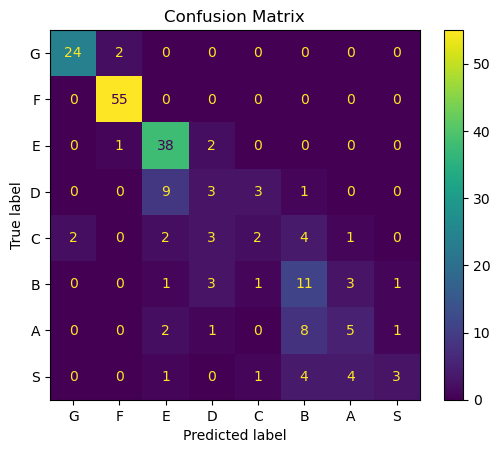

In [25]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_dev, y_dev_pred)

display_labels = ["G","F", "E", "D", "C", "B", "A", "S"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

## Model using dataset after PCA

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)
X_dev_pca = pca.transform(X_dev)
X_test_pca = pca.transform(X_test)

pca_model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    alpha=0.0001,
    max_iter=2000,
    random_state=42
)

pca_model.fit(X_train_pca, y_train)

,hidden_layer_sizes,"(10,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,2000
,shuffle,True
,random_state,42


### Accuracy

In [7]:
y_train_pred = pca_model.predict(X_train_pca)
y_dev_pred = pca_model.predict(X_dev_pca)

train_accuracy = accuracy_score(y_train, y_train_pred)
print("Train accuracy:", train_accuracy)
dev_accuracy = accuracy_score(y_dev, y_dev_pred)
print("Dev accuracy:", dev_accuracy)

class_report = classification_report(y_dev, y_dev_pred, target_names=["G", "F", "E", "D", "C", "B", "A", "S"])
print("Classification Report:\n", class_report)

Train accuracy: 0.7330508474576272
Dev accuracy: 0.698019801980198
Classification Report:
               precision    recall  f1-score   support

           G       0.92      0.92      0.92        26
           F       0.93      1.00      0.96        55
           E       0.70      0.90      0.79        41
           D       0.27      0.19      0.22        16
           C       0.18      0.14      0.16        14
           B       0.47      0.70      0.56        20
           A       0.75      0.18      0.29        17
           S       0.38      0.23      0.29        13

    accuracy                           0.70       202
   macro avg       0.57      0.53      0.52       202
weighted avg       0.68      0.70      0.67       202



### Plot visualization

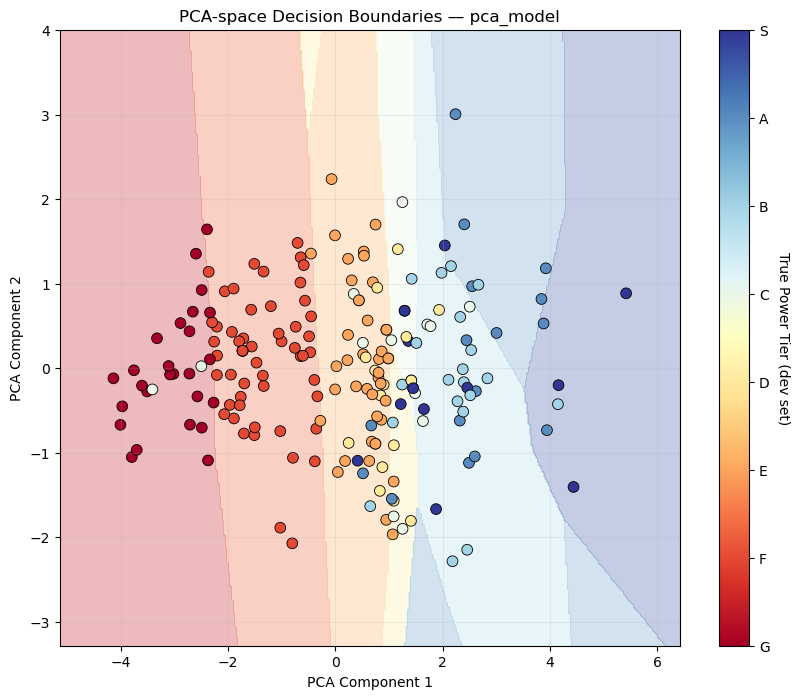

In [27]:
import numpy as np
import matplotlib.pyplot as plt

label_names = ["G", "F", "E", "D", "C", "B", "A", "S"]

x_min, x_max = X_dev_pca[:, 0].min() - 1.0, X_dev_pca[:, 0].max() + 1.0
y_min, y_max = X_dev_pca[:, 1].min() - 1.0, X_dev_pca[:, 1].max() + 1.0
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
grid = np.c_[xx.ravel(), yy.ravel()]

Z = pca_model.predict(grid)
Z = Z.reshape(xx.shape)

# Plotting
plt.figure(figsize=(10, 8))
cmap = plt.cm.RdYlBu
plt.contourf(xx, yy, Z, levels=np.arange(-0.5, len(label_names), 1), cmap=cmap, alpha=0.3)

sc = plt.scatter(X_dev_pca[:, 0], X_dev_pca[:, 1], c=y_dev, cmap=cmap, s=60, edgecolor="k", linewidth=0.6)

cbar = plt.colorbar(sc, ticks=np.arange(len(label_names)))
cbar.ax.set_yticklabels(label_names)
cbar.set_label('True Power Tier (dev set)', rotation=270, labelpad=15)

plt.title("PCA-space Decision Boundaries — pca_model")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True, alpha=0.2)
plt.show()